In [1]:
# Célula 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, make_scorer
import optuna
from sklearn.model_selection import StratifiedKFold
import joblib
import warnings
warnings.filterwarnings('ignore')


print("=" * 80)
print("🔧 OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 80)
print("\n💡 Objetivo:")
print("   • Refinar o melhor modelo encontrado")
print("   • Usar RandomizedSearchCV (mais rápido que Grid)")
print("   • Maximizar AUC-ROC")

🔧 OTIMIZAÇÃO DE HIPERPARÂMETROS

💡 Objetivo:
   • Refinar o melhor modelo encontrado
   • Usar RandomizedSearchCV (mais rápido que Grid)
   • Maximizar AUC-ROC


C:\Users\wesle\anaconda3\envs\credit_score\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Célula 2: Identificar Melhor Modelo
print("\n" + "=" * 80)
print("🏆 IDENTIFICANDO MELHOR MODELO")
print("=" * 80)

results_df = pd.read_csv('../reports/model_results.csv')
results_df_sorted = results_df.sort_values('test_auc', ascending=False)

print("\n📊 Ranking Atual:")
print(results_df_sorted[['model_name', 'test_auc']].to_string(index=False))

best_model_name = results_df_sorted.iloc[0]['model_name']
best_auc = results_df_sorted.iloc[0]['test_auc']

print(f"\n🥇 Modelo a otimizar: {best_model_name}")
print(f"   AUC atual: {best_auc:.4f}")
print(f"   Objetivo: Melhorar este resultado!")


🏆 IDENTIFICANDO MELHOR MODELO

📊 Ranking Atual:
                    model_name  test_auc
                      LightGBM  0.859706
                 Random Forest  0.856266
                       XGBoost  0.854460
Logistic Regression (Baseline)  0.719505

🥇 Modelo a otimizar: LightGBM
   AUC atual: 0.8597
   Objetivo: Melhorar este resultado!


In [4]:
# Célula 3: Carregar Dados
print("\n" + "=" * 80)
print("📊 CARREGANDO DADOS")
print("=" * 80)

train_df = pd.read_csv('../data/final/no_scale_train_balanced.csv')
test_df = pd.read_csv('../data/final/no_scale_test.csv')

target_col = 'inadipl_90dias_ult2anos'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

X = X_train.values
y = y_train.values


print(f"✅ Dados carregados:")
print(f"   Train: {X_train.shape}")
print(f"   Test:  {X_test.shape}")


📊 CARREGANDO DADOS
✅ Dados carregados:
   Train: (222762, 28)
   Test:  (29847, 28)


In [31]:
import xgboost as xgb

In [38]:
# Função para calcular KS-statistic
def ks_statistic(y_true, y_pred):
    data = np.array(list(zip(y_true, y_pred)))
    data = data[np.argsort(data[:,1])]
    
    cum_good = np.cumsum(data[:,0] == 0) / sum(data[:,0] == 0)
    cum_bad = np.cumsum(data[:,0] == 1) / sum(data[:,0] == 1)
    
    ks = np.max(np.abs(cum_good - cum_bad))
    return ks

# Função objetivo multiobjetivo
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'auc'
    }

    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores, ks_scores = [], []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:,1]

        auc_scores.append(roc_auc_score(y_test, y_pred))
        ks_scores.append(ks_statistic(y_test, y_pred))

    return np.mean(auc_scores), np.mean(ks_scores)



# Criando estudo multiobjetivo
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=50)

print("Melhores parâmetros encontrados:")
print(study.best_trials[0].params)
print("Melhor AUC:", study.best_trials[0].values[0])
print("Melhor KS:", study.best_trials[0].values[1])


[I 2026-03-05 20:30:24,615] A new study created in memory with name: no-name-27cd92f3-6871-44a8-96f8-cbf742878f03
[I 2026-03-05 20:30:47,717] Trial 0 finished with values: [0.9901263386165319, 0.929835448257861] and parameters: {'n_estimators': 433, 'max_depth': 6, 'learning_rate': 0.1201596273285426, 'num_leaves': 38, 'subsample': 0.6507565399198524, 'colsample_bytree': 0.619402402111844, 'min_child_samples': 22, 'reg_alpha': 0.2001096315130746, 'reg_lambda': 1.6410501093079117}.
[I 2026-03-05 20:31:18,643] Trial 1 finished with values: [0.9901316143835242, 0.9305356833921173] and parameters: {'n_estimators': 485, 'max_depth': 8, 'learning_rate': 0.098166444909632, 'num_leaves': 47, 'subsample': 0.6002766761264712, 'colsample_bytree': 0.6262550391027343, 'min_child_samples': 34, 'reg_alpha': 0.8225966046614536, 'reg_lambda': 0.5838106913114409}.
[I 2026-03-05 20:31:45,949] Trial 2 finished with values: [0.9901656017271998, 0.927384353243523] and parameters: {'n_estimators': 427, 'max_

Melhores parâmetros encontrados:
{'n_estimators': 388, 'max_depth': 9, 'learning_rate': 0.08151359090494836, 'num_leaves': 95, 'subsample': 0.8740795874398177, 'colsample_bytree': 0.8699524762170957, 'min_child_samples': 10, 'reg_alpha': 0.5740587551233659, 'reg_lambda': 1.3801546226307337}
Melhor AUC: 0.9902254029764268
Melhor KS: 0.9310474445261688


In [39]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Função KS-statistic
def ks_statistic(y_true, y_pred):
    data = np.array(list(zip(y_true, y_pred)))
    data = data[np.argsort(data[:,1])]
    
    cum_good = np.cumsum(data[:,0] == 0) / sum(data[:,0] == 0)
    cum_bad = np.cumsum(data[:,0] == 1) / sum(data[:,0] == 1)
    
    return np.max(np.abs(cum_good - cum_bad))

# Função objetivo multiobjetivo (AUC + KS)
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2),
        'random_state': 42,
        'n_jobs': -1
    }

    model = lgb.LGBMClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores, ks_scores = [], []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:,1]

        auc_scores.append(roc_auc_score(y_test, y_pred))
        ks_scores.append(ks_statistic(y_test, y_pred))

    return np.mean(auc_scores), np.mean(ks_scores)

# Criando estudo multiobjetivo
study_lgbm = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=50)

print("Melhores parâmetros encontrados:")
print(study.best_trials[0].params)
print("Melhor AUC:", study.best_trials[0].values[0])
print("Melhor KS:", study.best_trials[0].values[1])


[I 2026-03-05 20:53:21,609] A new study created in memory with name: no-name-8fbf1d31-56ea-4862-8af7-9a0e85a50759
[I 2026-03-05 20:54:01,840] Trial 50 finished with values: [0.990344612001967, 0.9284707580801651] and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.0404851443542992, 'num_leaves': 93, 'subsample': 0.6679560014603506, 'colsample_bytree': 0.85456154229905, 'min_child_samples': 17, 'reg_alpha': 0.14911420804106978, 'reg_lambda': 1.4563738808608193}.
[I 2026-03-05 20:54:31,396] Trial 51 finished with values: [0.9900585755936154, 0.929332608569329] and parameters: {'n_estimators': 480, 'max_depth': 5, 'learning_rate': 0.12993679379110643, 'num_leaves': 92, 'subsample': 0.6605770278852744, 'colsample_bytree': 0.7498024882473129, 'min_child_samples': 48, 'reg_alpha': 0.7490116920485431, 'reg_lambda': 0.828644335954505}.
[I 2026-03-05 20:55:11,130] Trial 52 finished with values: [0.9902902096168512, 0.9311641592485118] and parameters: {'n_estimators': 390, '

Melhores parâmetros encontrados:
{'n_estimators': 460, 'max_depth': 11, 'learning_rate': 0.08362801884791318, 'num_leaves': 98, 'subsample': 0.8807480200763557, 'colsample_bytree': 0.6465210578960283, 'min_child_samples': 46, 'reg_alpha': 0.6498855540699856, 'reg_lambda': 1.5867417194470002}
Melhor AUC: 0.9901423833433954
Melhor KS: 0.9315592310510347


In [42]:
# -----------------------------
# XGBoost com melhores parâmetros do Optuna
# -----------------------------
# Estudo para XGBoost
study_xgb = optuna.create_study(directions=['maximize','maximize'])
study_xgb.optimize(objective_xgb, n_trials=50)

# Estudo para LightGBM
study_lgbm = optuna.create_study(directions=['maximize','maximize'])
study_lgbm.optimize(objective_lgbm, n_trials=50)

best_params_xgb = study.best_trials[0].params   # pega o primeiro trial ótimo

xgb_best = xgb.XGBClassifier(
    **best_params_xgb,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

xgb_best.fit(X_train, y_train)

y_pred_proba_xgb_tuned = xgb_best.predict_proba(X_test)[:, 1]
xgb_tuned_auc = roc_auc_score(y_test, y_pred_proba_xgb_tuned)
xgb_tuned_ks = ks_statistic(y_test, y_pred_proba_xgb_tuned)

print(f"📊 XGB Tuned - Test AUC: {xgb_tuned_auc:.4f}")
print(f"📊 XGB Tuned - Test KS : {xgb_tuned_ks:.4f}")

# -----------------------------
# LightGBM com melhores parâmetros do Optuna
# -----------------------------
best_params_lgbm = study_lgbm.best_trials[0].params   # pega o primeiro trial ótimo

lgbm_best = lgb.LGBMClassifier(
    **best_params_lgbm,
    random_state=42,
    n_jobs=-1
)

lgbm_best.fit(X_train, y_train)

y_pred_proba_lgbm_tuned = lgbm_best.predict_proba(X_test)[:, 1]
lgbm_tuned_auc = roc_auc_score(y_test, y_pred_proba_lgbm_tuned)
lgbm_tuned_ks = ks_statistic(y_test, y_pred_proba_lgbm_tuned)

print(f"📊 LGBM Tuned - Test AUC: {lgbm_tuned_auc:.4f}")
print(f"📊 LGBM Tuned - Test KS : {lgbm_tuned_ks:.4f}")


[I 2026-03-06 02:17:34,155] A new study created in memory with name: no-name-e9a62034-d889-46a8-a928-e29bdbfcbefa
[I 2026-03-06 02:18:50,146] Trial 0 finished with values: [0.9903916689738441, 0.9315772359596514] and parameters: {'n_estimators': 330, 'max_depth': 12, 'learning_rate': 0.09828156239396227, 'subsample': 0.8734800126990749, 'colsample_bytree': 0.7667341726864082, 'min_child_weight': 3, 'gamma': 0.06061752798090264, 'reg_alpha': 0.8932275447212027, 'reg_lambda': 1.0804561606040923}.
[I 2026-03-06 02:20:01,774] Trial 1 finished with values: [0.9904718588488735, 0.9302843385112082] and parameters: {'n_estimators': 446, 'max_depth': 9, 'learning_rate': 0.07579104373133286, 'subsample': 0.879490638549937, 'colsample_bytree': 0.7732130911700086, 'min_child_weight': 1, 'gamma': 0.23868999437031252, 'reg_alpha': 0.37907953853477516, 'reg_lambda': 1.4212368206874957}.
[I 2026-03-06 02:21:24,404] Trial 2 finished with values: [0.9895273434074735, 0.9295930187770394] and parameters: 

KeyboardInterrupt: 

In [45]:
lgbm_tuned_auc = roc_auc_score(y_test, y_pred_proba_lgbm_tuned)



📊 COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO

📊 Comparação Final:
           Modelo  Test AUC  Test KS  Melhoria AUC
 XGBoost Original  0.854460      NaN      0.000000
    XGBoost Tuned  0.839510 0.521659     -0.014949
LightGBM Original  0.859706      NaN      0.000000
   LightGBM Tuned  0.857153 0.560947     -0.002553


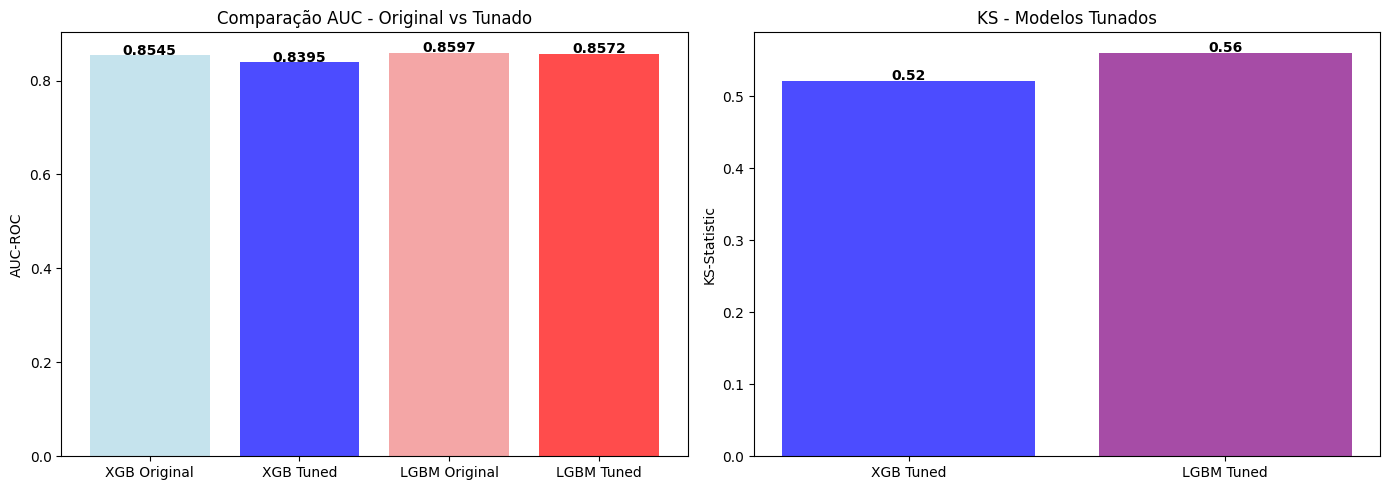

In [47]:
print("\n" + "=" * 80)
print("📊 COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO")
print("=" * 80)

# Carregar modelos originais
xgb_original = joblib.load('../models/xgboost.pkl')
lgbm_original = joblib.load('../models/lightgbm.pkl')

xgb_original_auc = roc_auc_score(y_test, xgb_original.predict_proba(X_test)[:, 1])
lgbm_original_auc = roc_auc_score(y_test, lgbm_original.predict_proba(X_test)[:, 1])

# Comparação final AUC + KS
comparison_tuning = pd.DataFrame({
    'Modelo': ['XGBoost Original', 'XGBoost Tuned', 'LightGBM Original', 'LightGBM Tuned'],
    'Test AUC': [xgb_original_auc, xgb_tuned_auc, lgbm_original_auc, lgbm_tuned_auc],
    'Test KS': [np.nan, xgb_tuned_ks, np.nan, lgbm_tuned_ks],  # KS só nos tunados
    'Melhoria AUC': [0, xgb_tuned_auc - xgb_original_auc, 0, lgbm_tuned_auc - lgbm_original_auc]
})

print("\n📊 Comparação Final:")
print(comparison_tuning.to_string(index=False))

# Visualização lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico AUC
axes[0].bar(['XGB Original','XGB Tuned','LGBM Original','LGBM Tuned'],
            [xgb_original_auc, xgb_tuned_auc, lgbm_original_auc, lgbm_tuned_auc],
            color=['lightblue','blue','lightcoral','red'], alpha=0.7)
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Comparação AUC - Original vs Tunado')
for i, v in enumerate([xgb_original_auc, xgb_tuned_auc, lgbm_original_auc, lgbm_tuned_auc]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Gráfico KS (apenas tunados)
axes[1].bar(['XGB Tuned','LGBM Tuned'],
            [xgb_tuned_ks, lgbm_tuned_ks],
            color=['blue','purple'], alpha=0.7)
axes[1].set_ylabel('KS-Statistic')
axes[1].set_title('KS - Modelos Tunados')
for i, v in enumerate([xgb_tuned_ks, lgbm_tuned_ks]):
    axes[1].text(i, v + 0.001, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



📊 ANÁLISE DOS RESULTADOS DO CV

🔍 XGBoost - Top 5 Configurações (AUC + KS):
 values_0  values_1
 0.990472  0.930284
 0.990392  0.931577
 0.990260  0.927645
 0.990122  0.925436
 0.990015  0.927654

🔍 LightGBM - Top 5 Configurações (AUC + KS):
 values_0  values_1
 0.990515  0.930051
 0.990496  0.929916
 0.990384  0.928650
 0.990377  0.931164
 0.990355  0.929791


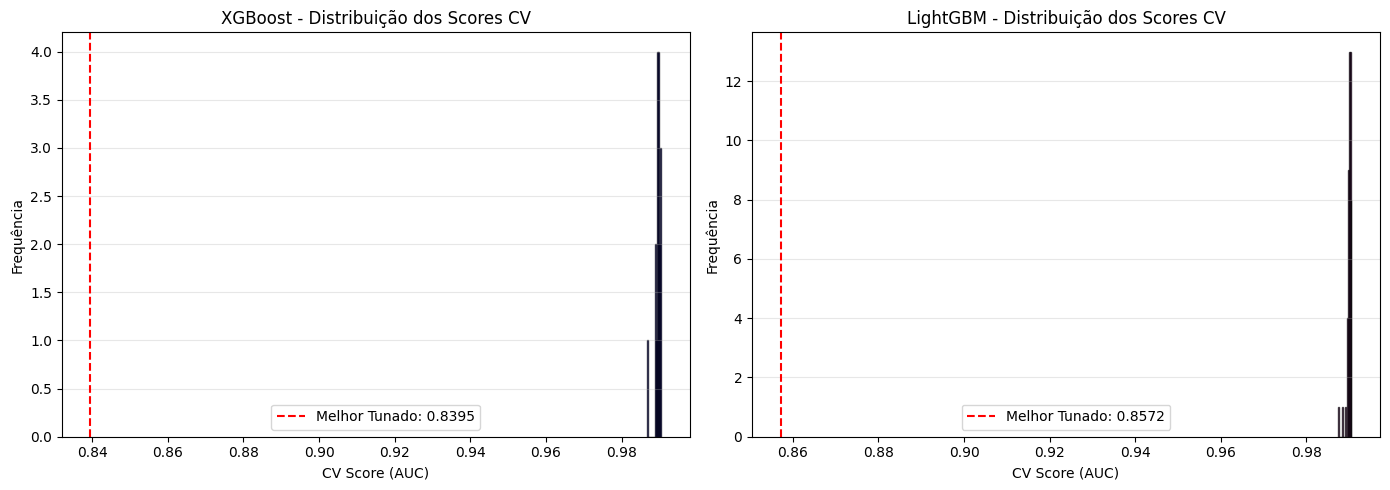


📊 ANÁLISE DO KS - MODELOS TUNADOS
XGBoost Tunado - KS: 0.5217
LightGBM Tunado - KS: 0.5609
✅ XGBoost Tunado apresenta KS acima de 30, considerado bom para modelos de crédito.
✅ LightGBM Tunado apresenta KS acima de 30, considerado bom para modelos de crédito.
🌟 XGBoost Tunado apresenta KS acima de 40, excelente poder discriminativo.
🌟 LightGBM Tunado apresenta KS acima de 40, excelente poder discriminativo.


In [49]:
print("\n" + "=" * 80)
print("📊 ANÁLISE DOS RESULTADOS DO CV")
print("=" * 80)

# -----------------------------
# XGBoost - Resultados do CV
# -----------------------------
xgb_cv_results = study_xgb.trials_dataframe()
xgb_cv_results = xgb_cv_results.sort_values('values_0', ascending=False)  # AUC como primeira métrica

print("\n🔍 XGBoost - Top 5 Configurações (AUC + KS):")
print(xgb_cv_results[['values_0','values_1']].head().to_string(index=False))

# -----------------------------
# LightGBM - Resultados do CV
# -----------------------------
lgbm_cv_results = study_lgbm.trials_dataframe()
lgbm_cv_results = lgbm_cv_results.sort_values('values_0', ascending=False)

print("\n🔍 LightGBM - Top 5 Configurações (AUC + KS):")
print(lgbm_cv_results[['values_0','values_1']].head().to_string(index=False))

# -----------------------------
# Distribuição dos Scores CV
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
axes[0].hist(xgb_cv_results['values_0'], bins=15, color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(xgb_tuned_auc, color='red', linestyle='--', 
               label=f'Melhor Tunado: {xgb_tuned_auc:.4f}')
axes[0].set_xlabel('CV Score (AUC)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('XGBoost - Distribuição dos Scores CV')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# LightGBM
axes[1].hist(lgbm_cv_results['values_0'], bins=15, color='purple', alpha=0.7, edgecolor='black')
axes[1].axvline(lgbm_tuned_auc, color='red', linestyle='--', 
               label=f'Melhor Tunado: {lgbm_tuned_auc:.4f}')
axes[1].set_xlabel('CV Score (AUC)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('LightGBM - Distribuição dos Scores CV')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Análise do KS Tunado
# -----------------------------
print("\n" + "=" * 80)
print("📊 ANÁLISE DO KS - MODELOS TUNADOS")
print("=" * 80)

print(f"XGBoost Tunado - KS: {xgb_tuned_ks:.4f}")
print(f"LightGBM Tunado - KS: {lgbm_tuned_ks:.4f}")

if xgb_tuned_ks >= 0.30:
    print("✅ XGBoost Tunado apresenta KS acima de 30, considerado bom para modelos de crédito.")
if lgbm_tuned_ks >= 0.30:
    print("✅ LightGBM Tunado apresenta KS acima de 30, considerado bom para modelos de crédito.")

if xgb_tuned_ks >= 0.40:
    print("🌟 XGBoost Tunado apresenta KS acima de 40, excelente poder discriminativo.")
if lgbm_tuned_ks >= 0.40:
    print("🌟 LightGBM Tunado apresenta KS acima de 40, excelente poder discriminativo.")


In [51]:
# Célula 9: Selecionar Modelo Final
print("\n" + "=" * 80)
print("🏆 SELECIONANDO MODELO FINAL")
print("=" * 80)

# Comparar todos os modelos tunados
final_comparison_auc = {
    'XGBoost Tuned': xgb_tuned_auc,
    'LightGBM Tuned': lgbm_tuned_auc
}

final_comparison_ks = {
    'XGBoost Tuned': xgb_tuned_ks,
    'LightGBM Tuned': lgbm_tuned_ks
}

# Seleção baseada em KS (critério principal em bureaus)
best_final_model = max(final_comparison_ks, key=final_comparison_ks.get)
best_final_ks = final_comparison_ks[best_final_model]
best_final_auc = final_comparison_auc[best_final_model]

print(f"\n🥇 MODELO FINAL SELECIONADO: {best_final_model}")
print(f"   Test KS : {best_final_ks:.4f}")
print(f"   Test AUC: {best_final_auc:.4f}")

# Definir modelo final
if best_final_model == 'XGBoost Tuned':
    final_model = xgb_best
    model_type = 'xgboost'
else:
    final_model = lgbm_best
    model_type = 'lightgbm'

# Comparação com baseline
print("\n📊 Comparação com Baseline Original (Logistic Regression):")
baseline_auc = results_df[results_df['model_name']=='Logistic Regression (Baseline)']['test_auc'].values[0]
print(f"   Baseline AUC: {baseline_auc:.4f}")
print(f"   {best_final_model} AUC: {best_final_auc:.4f}")
print(f"   Melhoria Total (AUC): +{(best_final_auc - baseline_auc):.4f}")

# Interpretação KS segundo benchmarks de mercado
if best_final_ks >= 0.30:
    print("✅ KS acima de 30: modelo aceitável para crédito.")
if best_final_ks >= 0.40:
    print("🌟 KS acima de 40: modelo excelente, forte poder discriminativo.")
if best_final_ks >= 0.50:
    print("🚀 KS acima de 50: modelo excepcional, raríssimo em dados reais.")



🏆 SELECIONANDO MODELO FINAL

🥇 MODELO FINAL SELECIONADO: LightGBM Tuned
   Test KS : 0.5609
   Test AUC: 0.8572

📊 Comparação com Baseline Original (Logistic Regression):
   Baseline AUC: 0.7195
   LightGBM Tuned AUC: 0.8572
   Melhoria Total (AUC): +0.1376
✅ KS acima de 30: modelo aceitável para crédito.
🌟 KS acima de 40: modelo excelente, forte poder discriminativo.
🚀 KS acima de 50: modelo excepcional, raríssimo em dados reais.


In [53]:
print("\n" + "=" * 80)
print("💾 SALVANDO MODELO FINAL")
print("=" * 80)

# Salvar modelo otimizado
final_model_path = f'../models/{model_type}_tuned_FINAL.pkl'
joblib.dump(final_model, final_model_path)
print(f"✅ Modelo final salvo: {final_model_path}")

# Salvar parâmetros vindos do Optuna
if best_final_model == 'XGBoost Tuned':
    best_params = study_xgb.best_trials[0].params
else:
    best_params = study_lgbm.best_trials[0].params

params_df = pd.DataFrame([best_params])
params_df.to_csv(f'../reports/{model_type}_best_params.csv', index=False)
print(f"✅ Parâmetros salvos: reports/{model_type}_best_params.csv")

# Atualizar resultados
from sklearn.metrics import f1_score, accuracy_score

y_pred_final = final_model.predict(X_test)
y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]

final_results = {
    'model_name': f'{model_type.upper()} (Tuned - FINAL)',
    'train_accuracy': accuracy_score(y_train, final_model.predict(X_train)),
    'train_f1': f1_score(y_train, final_model.predict(X_train)),
    'train_auc': roc_auc_score(y_train, final_model.predict_proba(X_train)[:, 1]),
    'test_accuracy': accuracy_score(y_test, y_pred_final),
    'test_f1': f1_score(y_test, y_pred_final),
    'test_auc': best_final_auc,
    'test_ks': best_final_ks,   # incluir KS no relatório final
    'n_features': X_train.shape[1]
}

results_df = pd.read_csv('../reports/model_results.csv')
results_df = pd.concat([results_df, pd.DataFrame([final_results])], ignore_index=True)
results_df.to_csv('../reports/model_results.csv', index=False)
print("✅ Resultados atualizados")



💾 SALVANDO MODELO FINAL
✅ Modelo final salvo: ../models/lightgbm_tuned_FINAL.pkl
✅ Parâmetros salvos: reports/lightgbm_best_params.csv
✅ Resultados atualizados


In [54]:
# Célula 11: Resumo Final
print("\n" + "=" * 80)
print("🎉 OTIMIZAÇÃO COMPLETA!")
print("=" * 80)

print(f"\n🏆 MODELO FINAL: {best_final_model}")
print(f"\n📊 Performance:")
print(f"   Test AUC:      {best_final_auc:.4f}")
print(f"   Test F1:       {final_results['test_f1']:.4f}")
print(f"   Test Accuracy: {final_results['test_accuracy']:.4f}")

print(f"\n🎯 Progressão do Projeto:")
baseline_auc = results_df[results_df['model_name']=='Logistic Regression (Baseline)']['test_auc'].values[0]
print(f"   1. Baseline (LR):     {baseline_auc:.4f}")
print(f"   2. Random Forest:     {results_df[results_df['model_name']=='Random Forest']['test_auc'].values[0]:.4f}")
print(f"   3. {model_type.upper()} Original:  {xgb_original_auc if model_type=='xgboost' else lgbm_original_auc:.4f}")
print(f"   4. {model_type.upper()} Tuned:     {best_final_auc:.4f} ⭐")
print(f"\n   Melhoria Total: +{(best_final_auc - baseline_auc):.4f} ({((best_final_auc - baseline_auc)/baseline_auc)*100:+.2f}%)")

print(f"\n💡 Parâmetros Otimizados:")
for param, value in list(best_params.items())[:5]:
    print(f"   {param:20s}: {value}")

print(f"\n🎯 PRÓXIMO:")
print(f"   Dia 20: Avaliação final completa e comparação")


🎉 OTIMIZAÇÃO COMPLETA!

🏆 MODELO FINAL: LightGBM Tuned

📊 Performance:
   Test AUC:      0.8572
   Test F1:       0.3445
   Test Accuracy: 0.9365

🎯 Progressão do Projeto:
   1. Baseline (LR):     0.7195
   2. Random Forest:     0.8563
   3. LIGHTGBM Original:  0.8597
   4. LIGHTGBM Tuned:     0.8572 ⭐

   Melhoria Total: +0.1376 (+19.13%)

💡 Parâmetros Otimizados:
   n_estimators        : 290
   max_depth           : 11
   learning_rate       : 0.059096568687231364
   num_leaves          : 105
   subsample           : 0.670498234780698

🎯 PRÓXIMO:
   Dia 20: Avaliação final completa e comparação
